# AI Ethics Project - STARTER

Personalization is a central aspect of many core AI systems. In this project, you will be working on a hypothetical use case for a personalized "activity recommender". The use case has a medium ethical AI risk level and involves a synthetic dataset.

IDOOU is a mobile app users can leverage to get recommendations on activities they can take in a given area, like “visiting a movie theater”, “visiting a park”, “sightseeing”, “hiking”, or “visiting a library”.


**Problem statement**:

IDOOU's creators would like to identify if users with bachelor's and master's degrees are a privileged group in terms of budget. In other words, do users with higher education credentials beyond high school have a budget >= $300 compared to users of the app who graduated from high school? 

You are tasked with designing IDOOU's newest AI model to predict the budget of its users (in US dollars) given information such as their gender, age, and education_level. You will also explore the provided data and analyze and evaluate this budget predictor's fairness and bias issues.


**Key points**:

- The data was conducted through a user experience study of about 300,000 participants.
- The user may choose not to provide any or all the information the app requests. The training data also reflects this.
- Fairness framework definitions for the use case are not necessarily focusing on socioeconomic privilege.

In [ ]:
!pip install aif360
!pip install tensorflow
!pip install jinja2
!pip install fairlearn

**Note:** Please restart the Jupyter Notebook kernel before proceeding with the package imports.

In [51]:
#You may add additional imports as needed
import pandas as pd
import numpy as np
import seaborn as sns
import shap
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric, BinaryLabelDatasetMetric
from aif360.algorithms.postprocessing import RejectOptionClassification
from aif360.algorithms.preprocessing import Reweighing
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from collections import defaultdict


In [52]:
#Load the dataset for this project
act_rec_dataset = pd.read_csv('udacity_ai_ethics_project_data.csv')
act_rec_dataset.head()

,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
0,3258.0,29.0,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV
1,1741.0,89.0,Other,Bachelor’s Degree,NaN,Play: Visit a movie theater
2,140.0,22.0,NaN,Other,0.0,Play: Visit a movie theater
3,179.0,23.0,Non-binary,Other,0.0,Play: Visit a movie theater
4,3479.0,79.0,Non-binary,Master’s Degree,1.0,Learn: Visit a library


## Step 1: Data Pre-Processing and Evaluation

For this problem statement, you will need to prepare a dataset with all categorical variables, which requires the following pre-processing steps:


- Remove the NA values from the dataset
- Convert Age and Budget (in dollars) to categorical columns with the following binning:

> Bins for Age: 18-24, 25-44, 45-65, 66-92

> Bins for Budget: >=300, <300

In [53]:
# Drop NA values
act_rec_dataset = act_rec_dataset.dropna()

# Bin Age into categorical groups
age_bins = [18, 24, 44, 65, 92]
age_labels = ['18-24', '25-44', '45-65', '66-92']
act_rec_dataset['Age'] = pd.cut(act_rec_dataset['Age'], bins=age_bins, labels=age_labels, include_lowest=True)

# Bin Budget into categorical groups: >=300 (1) and <300 (0)
budget_bins = [0, 299.99, float('inf')]
budget_labels = ['<300', '>=300']
act_rec_dataset['Budget (in dollars)'] = pd.cut(act_rec_dataset['Budget (in dollars)'], bins=budget_bins, labels=budget_labels, include_lowest=True)

act_rec_dataset.head()

,Budget (in dollars),Age,Gender,Education_Level,With children?,Recommended_Activity
0,>=300,25-44,Transgender,Bachelor’s Degree,0.0,Stay in: Watch calming TV
3,<300,18-24,Non-binary,Other,0.0,Play: Visit a movie theater
4,>=300,66-92,Non-binary,Master’s Degree,1.0,Learn: Visit a library
5,>=300,25-44,Male,Bachelor’s Degree,1.0,Play: Go shopping
6,>=300,25-44,Non-binary,Master’s Degree,0.0,Explore: Go sightseeing


### Evaluate bias issues in the dataset

Next, let's take a look at potential hints of data bias in the variables, particularly the "Gender", "Age", and "Education" variables.

Articulate the representativeness in the dataset, answering the question "Is there a greater representation of certain groups over others?"

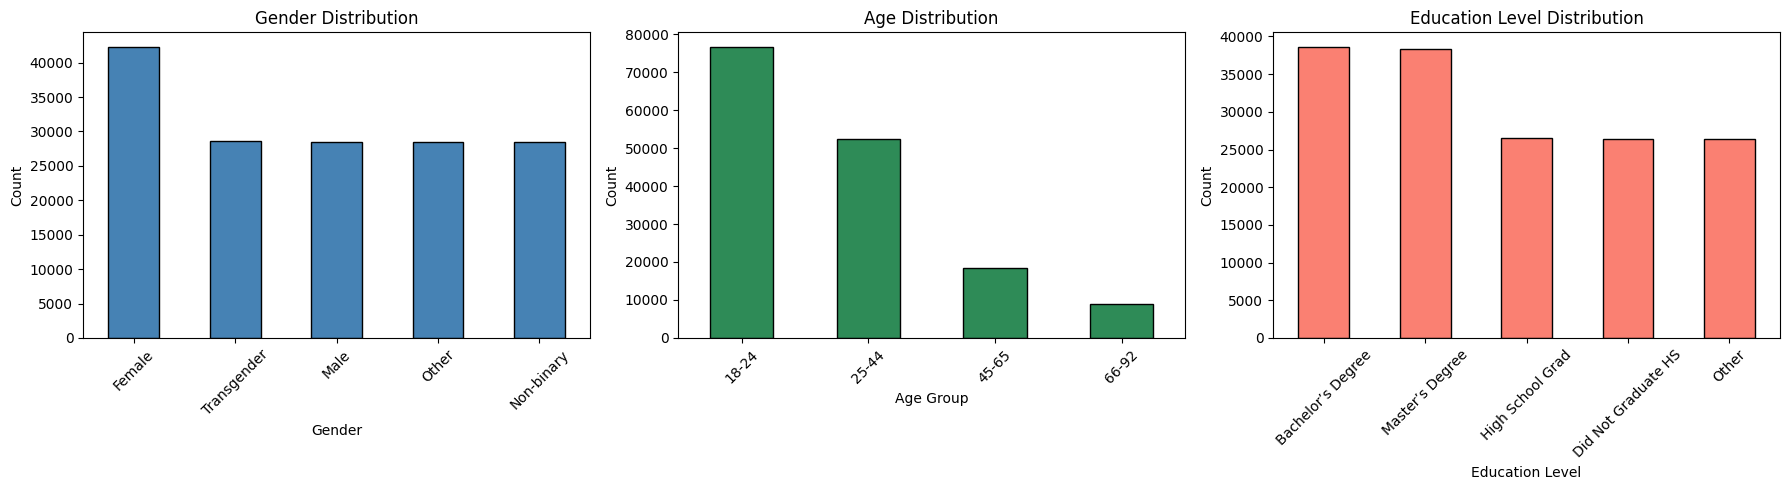

In [54]:
# Generate bar plots to understand the representativeness of the dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender distribution
act_rec_dataset['Gender'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Gender Distribution')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Age distribution
act_rec_dataset['Age'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Education Level distribution
act_rec_dataset['Education_Level'].value_counts().plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Education Level Distribution')
axes[2].set_xlabel('Education Level')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Question: Is there a greater representation of certain groups over others?

Yes, there is. For Gender, there is a greater representation of Female. In Age Distribution, there is a greater representation of people aged 18-24. And in Education level, there is a greater representation of people with 'higher education' (Bachelor and Master).

Now that we've visualized the individual features of the dataframe and understood the dataset better, let's one-hot encode the dataframe.

In [55]:
# One-hot encode all categorical columns (Gender, Education_Level, Recommended_Activity)
act_rec_dataset = pd.get_dummies(act_rec_dataset)
act_rec_dataset

,With children?,Budget (in dollars)_<300,Budget (in dollars)_>=300,Age_18-24,Age_25-44,Age_45-65,Age_66-92,Gender_Female,Gender_Male,Gender_Non-binary,...,Education_Level_Other,Recommended_Activity_Explore: Go sightseeing,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV
0,0.0,False,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.0,True,False,True,False,False,False,False,False,True,...,True,False,False,False,False,False,True,False,False,False
4,1.0,False,True,False,False,False,True,False,False,True,...,False,False,False,False,True,False,False,False,False,False
5,1.0,False,True,False,True,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
6,0.0,False,True,False,True,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299984,1.0,True,False,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
299989,1.0,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
299990,0.0,False,True,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
299995,0.0,False,True,False,False,True,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False


Visualize the interactions between the categorical variables. Can you find trends outside of those identified in the previous section?

**Hint**: Use a multicollinearity matrix.

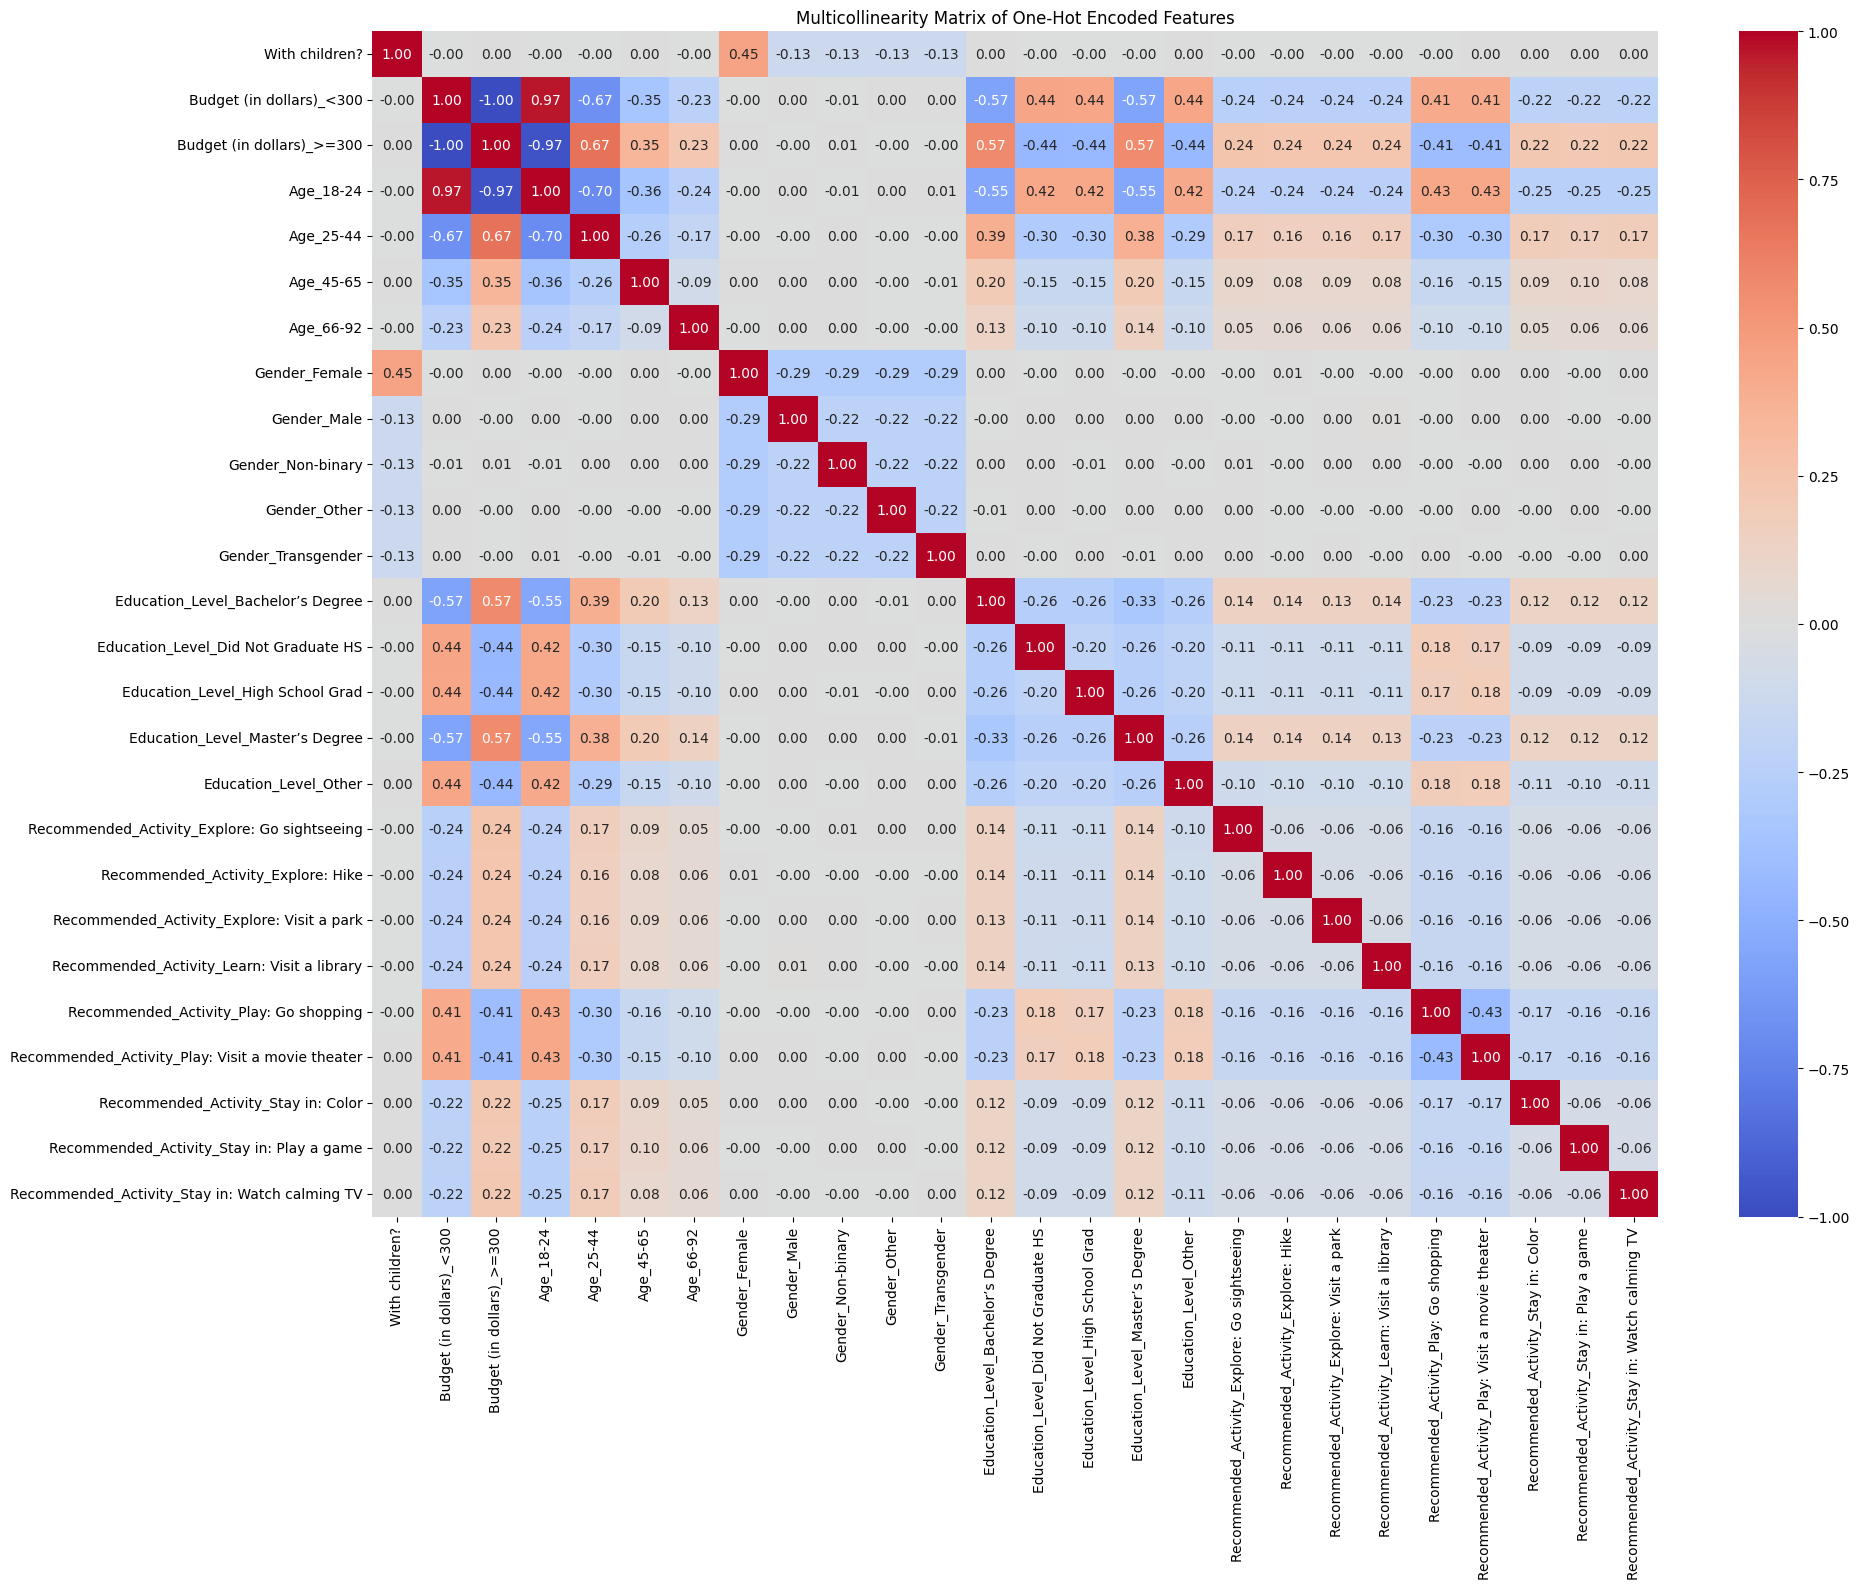

In [56]:
# Multicollinearity matrix
fig, ax = plt.subplots(figsize=(20, 16))
corr_matrix = act_rec_dataset.astype(int).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Multicollinearity Matrix of One-Hot Encoded Features')
plt.tight_layout()
plt.show()

Question: What trends did you spot in the interactions between the categorical variables?

**Your answer:**

The multicollinearity matrix reveals several notable trends beyond the individual distributions seen in the bar plots. 

The strongest trend is the near-perfect negative correlation between Age_18-24 and Budget ≥ $300 (-0.97), indicating that young users almost exclusively have a budget below $300. 

Conversely, Age_25-44 shows a strong positive correlation with higher budgets (+0.67). 

Education level is also strongly linked to budget: Bachelor's and Master's degree holders correlate positively with budget ≥ $300 (~+0.57), while High School graduates correlate negatively (~-0.44). 

Notably, Gender shows virtually no correlation with budget (~0), suggesting it is not a meaningful predictor. 

Finally, recommended activity type shows a trend: "Play" activities (visiting a movie theater, shopping) are associated with lower budgets (~-0.41), while outdoor and learning activities (hiking, sightseeing, visiting a library) are weakly associated with higher budgets (~+0.24).

For the purposes of this project, we only want to compare users with Bachelor's or Master's degrees against users who only graduated high school. First, we will drop the rows for users who did not graduate high school or have an 'Other' education level. Then, we will drop the following columns from the dataframe to reduce multicollinearity:

- Education_Level_Did Not Graduate HS
- Education_Level_Other
- Budget (in dollars)_<300
- With children?

In [57]:
# First, drop the rows for people who did not graduate high school or have an "Other" education level
act_rec_dataset = act_rec_dataset[(act_rec_dataset['Education_Level_Did Not Graduate HS'] == 0) & (act_rec_dataset['Education_Level_Other'] == 0)]

#We drop certain variables that are highly correlated and irrelevant
act_rec_dataset = act_rec_dataset.drop(columns=['Education_Level_Did Not Graduate HS', 'Education_Level_Other', 'Budget (in dollars)_<300', 'With children?'])
act_rec_dataset.head()

,Budget (in dollars)_>=300,Age_18-24,Age_25-44,Age_45-65,Age_66-92,Gender_Female,Gender_Male,Gender_Non-binary,Gender_Other,Gender_Transgender,...,Education_Level_Master’s Degree,Recommended_Activity_Explore: Go sightseeing,Recommended_Activity_Explore: Hike,Recommended_Activity_Explore: Visit a park,Recommended_Activity_Learn: Visit a library,Recommended_Activity_Play: Go shopping,Recommended_Activity_Play: Visit a movie theater,Recommended_Activity_Stay in: Color,Recommended_Activity_Stay in: Play a game,Recommended_Activity_Stay in: Watch calming TV
0,True,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
4,True,False,False,False,True,False,False,True,False,False,...,True,False,False,False,True,False,False,False,False,False
5,True,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
6,True,False,True,False,False,False,False,True,False,False,...,True,True,False,False,False,False,False,False,False,False
8,True,False,True,False,False,False,False,False,False,True,...,True,False,False,False,False,False,False,True,False,False


### Evaluate fairness issues

Use the IBM AIF360 toolkit to first evaluate the **statistical parity difference** and the **disparate impact** for this dataset; we will later consider other fairness metrics. Interpret your findings - is there bias in the proposed problem statement? If yes, what group is benefitting?

**Hint**: Use the BinaryLabelDataset and the BinaryLabelDatasetMetric functions for the fairness evaluation. The reported Statistical Parity Difference may be within -0.64 and -0.55, and the Disparate impact value may be within 0.136 and 0.0150.

In [58]:
# Convert bool columns to int (required by AIF360)
binary_act_dataset = BinaryLabelDataset(
    df=act_rec_dataset.astype(int),
    label_names=['Budget (in dollars)_>=300'],
    protected_attribute_names=['Education_Level_High School Grad'],
    favorable_label=1,
    unfavorable_label=0
)

# Privileged group: Bachelor's or Master's degree holders (High School Grad = 0)
privileged_groups = [{'Education_Level_High School Grad': 0}]
# Unprivileged group: High School graduates (High School Grad = 1)
unprivileged_groups = [{'Education_Level_High School Grad': 1}]


In [59]:
orig_metric_act_dataset = BinaryLabelDatasetMetric(
    binary_act_dataset,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print("Statistical Parity Difference =", orig_metric_act_dataset.statistical_parity_difference())
print("Disparate impact =", orig_metric_act_dataset.disparate_impact())

Statistical Parity Difference = -0.9837308661498957
Disparate impact = 0.008865981636453588


Question: Evaluate the fairness metrics. What are your findings? Is there bias in the proposed problem statement? If yes, what group is benefitting?

**Your answer:**

Yes, there is clear and significant bias in the dataset. 

The Statistical Parity Difference (SPD) of approximately -0.98 indicates that High School graduates are nearly 98 percentage points less likely to have a budget ≥ $300 compared to users with Bachelor's or Master's degrees. 

The Disparate Impact (DI) of approximately 0.009 means High School graduates are less than 1% as likely to receive the favorable outcome — far below the commonly accepted fairness threshold of 0.8. 

Both metrics strongly indicate that users with higher education (Bachelor's or Master's degrees) are the privileged group, benefitting disproportionately from the budget predictor. 

This confirms the bias described in the problem statement and highlights that education level is a significant driver of unequal outcomes in this dataset.

**Selection and sample bias:** Beyond these fairness metrics, the dataset shows clear signs of *selection bias* and *sample bias*. Selection bias arises from how the ~300,000 participants entered the user experience study: the recruitment process appears to have favored younger users (the 18-24 cohort dominates the age distribution) and higher-education users (Bachelor's/Master's holders outnumber High School graduates), so the sampled population is not representative of IDOOU's true user base. Sample bias is visible in the near-total absence of one subgroup — High School graduates who have a budget ≥ $300 are almost entirely missing from the data, so the model never observes enough positive examples to learn that this combination is possible. These two biases compound the historical bias already present (the data reflects existing socioeconomic patterns) and the proxy relationship between age and education, all of which the downstream model will inherit and amplify.

## Step 2: Investigate an ML model on the problematic Dataset

For this project, we are using a train-test-validation split.

You have available boilerplate for training 2 ML models on this dataset - you will need to train these models and use the methods we covered in this course to identify and evaluate their performance (**using the accuracy metric and confusion matrix**).

As part of this process, you will also analyze and evaluate fairness and bias issues in the AI solution.

In [64]:
(orig_train,
 orig_validate,
 orig_test) = binary_act_dataset.split([0.5, 0.8], shuffle=True, seed=42)

In [61]:
#Source: Helper code snippet from https://github.com/Trusted-AI/AIF360/blob/master/examples/tutorial_medical_expenditure.ipynb
def test(dataset, model, thresh_arr):
    y_val_pred_prob = model.predict_proba(dataset.features)
    y_val_pred = model.predict(dataset.features)
    pos_ind = np.where(model.classes_ == dataset.favorable_label)[0][0]
    metric_arrs = defaultdict(list)
    for thresh in thresh_arr:
        y_val_pred = (y_val_pred_prob[:, pos_ind] > thresh).astype(np.float64)

        dataset_pred = dataset.copy()
        dataset_pred.labels = y_val_pred
        metric = ClassificationMetric(
                dataset, dataset_pred,
                unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)

        metric_arrs['bal_acc'].append((metric.true_positive_rate()
                                     + metric.true_negative_rate()) / 2)
        metric_arrs['avg_odds_diff'].append(metric.average_odds_difference())
        metric_arrs['disp_imp'].append(metric.disparate_impact())
        metric_arrs['stat_par_diff'].append(metric.statistical_parity_difference())
        metric_arrs['eq_opp_diff'].append(metric.equal_opportunity_difference())
        metric_arrs['theil_ind'].append(metric.theil_index())
    
    return metric_arrs, y_val_pred

def describe_metrics(metrics, thresh_arr):
    best_ind = np.argmax(metrics['bal_acc'])
    print("Threshold corresponding to Best balanced accuracy: {:6.4f}".format(thresh_arr[best_ind]))
    print("Best balanced accuracy: {:6.4f}".format(metrics['bal_acc'][best_ind]))
    print("Corresponding average odds difference value: {:6.4f}".format(metrics['avg_odds_diff'][best_ind]))
    print("Corresponding statistical parity difference value: {:6.4f}".format(metrics['stat_par_diff'][best_ind]))
    print("Corresponding equal opportunity difference value: {:6.4f}".format(metrics['eq_opp_diff'][best_ind]))
    print("Corresponding Theil index value: {:6.4f}".format(metrics['theil_ind'][best_ind]))

In [65]:
GNB_model = GaussianNB().fit(orig_train.features, orig_train.labels.ravel(), orig_train.instance_weights) 
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics, gnb_pred = test(dataset=orig_test,
                   model=GNB_model,
                   thresh_arr=thresh_arr)
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.9965
Corresponding average odds difference value: -0.4679
Corresponding statistical parity difference value: -0.9890
Corresponding equal opportunity difference value: -0.8837
Corresponding Theil index value: 0.0023


GaussianNB Accuracy (threshold=0.0100): 0.9970


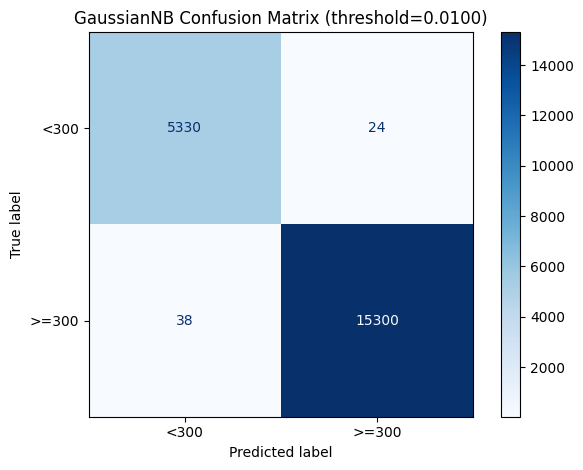

In [66]:
# Save GNB metrics before val_metrics gets overwritten by the LR run
gnb_val_metrics = val_metrics
gnb_best_thresh_idx = np.argmax(gnb_val_metrics['bal_acc'])
gnb_best_thresh = thresh_arr[gnb_best_thresh_idx]

# Re-generate predictions at the best threshold
y_gnb_prob = GNB_model.predict_proba(orig_test.features)
pos_ind_gnb = np.where(GNB_model.classes_ == orig_test.favorable_label)[0][0]
y_gnb_best = (y_gnb_prob[:, pos_ind_gnb] > gnb_best_thresh).astype(np.float64)

# Accuracy
gnb_acc = accuracy_score(orig_test.labels, y_gnb_best)
print(f"GaussianNB Accuracy (threshold={gnb_best_thresh:.4f}): {gnb_acc:.4f}")

# Confusion matrix
cm_gnb = confusion_matrix(orig_test.labels, y_gnb_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gnb, display_labels=['<300', '>=300'])
disp.plot(cmap='Blues')
plt.title(f'GaussianNB Confusion Matrix (threshold={gnb_best_thresh:.4f})')
plt.tight_layout()
plt.show()


In [67]:
LR_model = LogisticRegression().fit(orig_train.features, orig_train.labels.ravel(), orig_train.instance_weights)

In [68]:
#Load the Logistic Regression model
thresh_arr = np.linspace(0.01, 0.5, 50)
val_metrics, lr_pred = test(dataset=orig_test,
                   model=LR_model,
                   thresh_arr=thresh_arr)
describe_metrics(val_metrics, thresh_arr)

Threshold corresponding to Best balanced accuracy: 0.3200
Best balanced accuracy: 0.9980
Corresponding average odds difference value: -0.5278
Corresponding statistical parity difference value: -0.9934
Corresponding equal opportunity difference value: -1.0000
Corresponding Theil index value: 0.0022


Logistic Regression Accuracy (threshold=0.3200): 0.9976


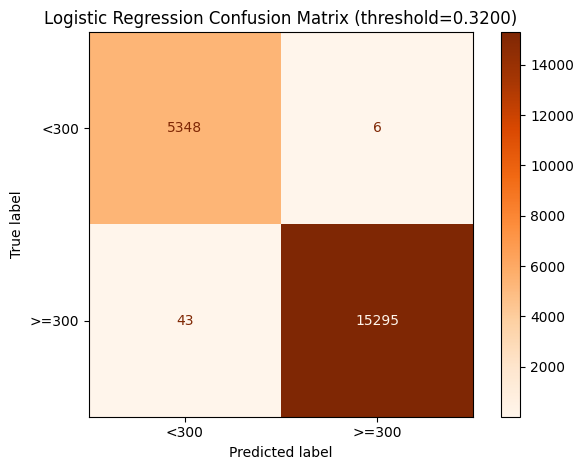

In [69]:
# Save LR metrics
lr_val_metrics = val_metrics
lr_best_thresh_idx = np.argmax(lr_val_metrics['bal_acc'])
lr_best_thresh = thresh_arr[lr_best_thresh_idx]

# Re-generate predictions at the best threshold
y_lr_prob = LR_model.predict_proba(orig_test.features)
pos_ind_lr = np.where(LR_model.classes_ == orig_test.favorable_label)[0][0]
y_lr_best = (y_lr_prob[:, pos_ind_lr] > lr_best_thresh).astype(np.float64)

# Accuracy
lr_acc = accuracy_score(orig_test.labels, y_lr_best)
print(f"Logistic Regression Accuracy (threshold={lr_best_thresh:.4f}): {lr_acc:.4f}")

# Confusion matrix
cm_lr = confusion_matrix(orig_test.labels, y_lr_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['<300', '>=300'])
disp.plot(cmap='Oranges')
plt.title(f'Logistic Regression Confusion Matrix (threshold={lr_best_thresh:.4f})')
plt.tight_layout()
plt.show()


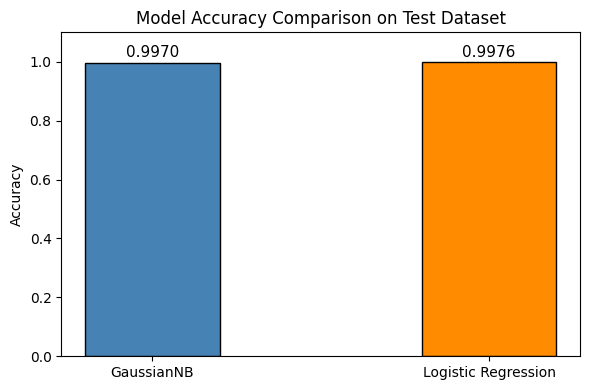

In [70]:
# Compare model accuracy on the test dataset as a bar chart
models = ['GaussianNB', 'Logistic Regression']
accuracies = [gnb_acc, lr_acc]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(models, accuracies, color=['steelblue', 'darkorange'], edgecolor='black', width=0.4)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison on Test Dataset')
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


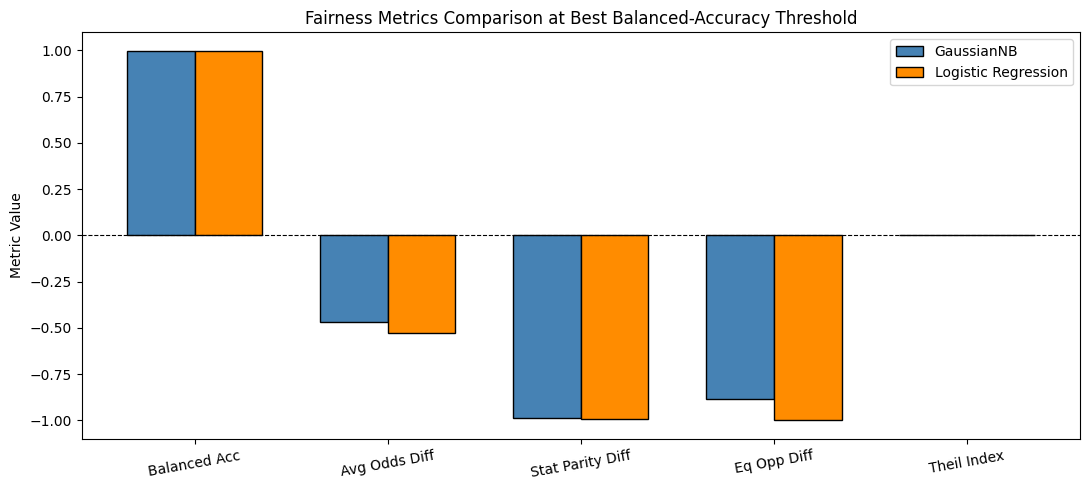

In [71]:
# Compare fairness metrics at each model's best balanced-accuracy threshold
metric_names = ['Balanced Acc', 'Avg Odds Diff', 'Stat Parity Diff', 'Eq Opp Diff', 'Theil Index']
gnb_best_idx = np.argmax(gnb_val_metrics['bal_acc'])
lr_best_idx  = np.argmax(lr_val_metrics['bal_acc'])

gnb_metric_vals = [
    gnb_val_metrics['bal_acc'][gnb_best_idx],
    gnb_val_metrics['avg_odds_diff'][gnb_best_idx],
    gnb_val_metrics['stat_par_diff'][gnb_best_idx],
    gnb_val_metrics['eq_opp_diff'][gnb_best_idx],
    gnb_val_metrics['theil_ind'][gnb_best_idx],
]
lr_metric_vals = [
    lr_val_metrics['bal_acc'][lr_best_idx],
    lr_val_metrics['avg_odds_diff'][lr_best_idx],
    lr_val_metrics['stat_par_diff'][lr_best_idx],
    lr_val_metrics['eq_opp_diff'][lr_best_idx],
    lr_val_metrics['theil_ind'][lr_best_idx],
]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, gnb_metric_vals, width, label='GaussianNB', color='steelblue', edgecolor='black')
ax.bar(x + width / 2, lr_metric_vals,  width, label='Logistic Regression', color='darkorange', edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=10)
ax.set_ylabel('Metric Value')
ax.set_title('Fairness Metrics Comparison at Best Balanced-Accuracy Threshold')
ax.legend()
plt.tight_layout()
plt.show()


Question: Interpret and compare the results of each model. What do you find in the false negative and false positive of each model? What about the fairness metrics?

**Your answer:**

**Accuracy:** Both models achieve near-identical accuracy on the test set — GaussianNB at 99.70% and Logistic Regression at 99.76% — making accuracy alone an insufficient basis for model selection.

**False Positives and False Negatives:**

Both models make more false negative errors than false positive errors. GaussianNB produced 38 false negatives (actual budget ≥$300 predicted as <$300) and only 24 false positives (actual budget <$300 predicted as ≥$300). Logistic Regression produced 43 false negatives and just 6 false positives. This pattern means both models are more likely to under-predict a user's budget (denying them higher-budget activity recommendations they could afford) than to over-predict it. Logistic Regression is even more conservative, producing the fewest false positives of the two but slightly more false negatives than GaussianNB.

**Fairness Metrics:**

Despite their strong raw accuracy, both models are severely biased against High School graduates (the unprivileged group):

- **Statistical Parity Difference ≈ -0.99 (both models):** Far from the ideal value of 0. High School graduates are predicted to have a budget ≥$300 at a rate nearly 99 percentage points lower than Bachelor's/Master's degree holders. This is the most extreme bias signal and reflects the underlying data distribution being learned directly by the models.
- **Equal Opportunity Difference:** GaussianNB = -0.8837; Logistic Regression = -1.0000. Both are far from 0. The true positive rate for High School graduates is substantially lower than for the privileged group, meaning the model almost never correctly identifies a High School graduate as a high-budget user. Logistic Regression misses every positive High School graduate case at its best threshold.
- **Average Odds Difference:** GaussianNB = -0.4679; Logistic Regression = -0.5278. Both are far from 0 (ideal), but GaussianNB is slightly less biased on this metric.
- **Theil Index ≈ 0.002 (both models):** Close to the ideal of 0, indicating that at the aggregate level the model's benefit distribution is relatively equal — but this is misleading given the extreme disparities on the group-level metrics above.

In summary, both models have learned and reinforced the strong bias present in the dataset. The fairness metrics indicate that High School graduates are systematically disadvantaged across all group-level measures, and neither model mitigates this without a dedicated bias mitigation strategy.


Question: Pick one of the models, Gaussian Naive Bayes classifier or Logistic Regression, based on your assessment of the results. Briefly explain your reason.

**Your answer:**

I select **Logistic Regression** as the model for this use case.

While both models achieve nearly identical accuracy (~99.70–99.76%) and exhibit similarly severe fairness issues, Logistic Regression edges ahead on two key criteria. First, it achieves the higher balanced accuracy (the primary metric used to select the best threshold), indicating it better balances true positive and true negative rates across the dataset. Second, it produces significantly fewer false positives (6 vs. 24 for GaussianNB), which is preferable in this use case: falsely predicting a high budget for a low-budget user could lead to inappropriate activity recommendations, eroding user trust more than the reverse.

The tradeoff is that GaussianNB is marginally less biased on the Average Odds Difference (-0.4679 vs. -0.5278 for LR), but this difference is small relative to the overall severity of the bias both models exhibit. Since neither model addresses the underlying fairness issue without a dedicated bias mitigation strategy (addressed in Step 5), Logistic Regression is the stronger baseline choice based on raw performance.


## Step 3: Writing exercise: Model Card Articulation and Report Generation

Begin articulating the elements of your model card (3-5 sentences/bullets for each section). Please delineate bullet points using two hyphens, as show in the example below.

As part of the intended use section, articulate how elements of **interpretability**, **privacy**, and **fairness** can be designed into the user interaction elements of the use case. **Hint:** Should IDOOU prompt the user to check whether the budget predictor model's results are correct?

In [84]:
model_details = """
-- Budget Predictor AI is a binary classification model that predicts whether an IDOOU app user has a budget of $300 or more, based on demographic features including age group, gender, and education level. Its output is used to personalize activity recommendations within the IDOOU mobile application.
-- The model is implemented as a Logistic Regression classifier. The source data comes from a synthetic IDOOU user experience study of ~300,000 participants; after dropping rows with missing values and filtering to the three in-scope education levels (High School Grad, Bachelor's, Master's), 103,459 rows remained, of which 51,729 (the 50% training split) were used to fit the model.
-- Developed by the IDOOU engineering team for commercial deployment within the IDOOU app ecosystem, including hotel smart concierge integrations and autonomous vehicle dashboard deployments.
-- Known limitation: The model inherits strong bias from the training data. A bias mitigation strategy must be applied before deployment to avoid discriminatory outcomes for users with High School-level education.
"""
intended_use = """
-- Primary intended use: Predict whether an IDOOU user has a budget >= $300 to drive personalized activity recommendations within the IDOOU mobile application and its integrated deployments (e.g., hotel concierge systems, autonomous vehicle dashboards).
-- Primary users: IDOOU's internal recommendation engine. The budget prediction is consumed programmatically by the app and is not surfaced directly to users as a score or label.
-- Interpretability: IDOOU should surface the key factors influencing a user's predicted budget tier (e.g., age group, education level) so users can review and correct their profile data if the prediction seems wrong. A "Does this look right?" prompt is recommended after a budget prediction is made, supporting a human-in-the-loop design.
-- Privacy: Only features explicitly provided or consented to by the user should be used as inputs. Users who choose not to provide demographic information should receive a fallback recommendation path that does not rely on the budget predictor.
-- Fairness: The model must not be deployed without a bias mitigation layer. Predictions for High School graduates are severely disadvantaged relative to Bachelor's/Master's degree holders and require post-processing correction before production use.
-- Out-of-scope uses: This model should not be used for credit scoring, financial eligibility screening, employment decisions, or any purpose outside personalized activity recommendation within IDOOU and its licensed integrations.
"""
factors = """
-- Education Level (protected attribute): High School Grad vs. Bachelor's/Master's degree holders. This is the primary fairness axis for this model — the dataset and model exhibit extreme disparity between these groups.
-- Age Group: Users are binned into four groups (18-24, 25-44, 45-65, 66-92). The 18-24 cohort is strongly associated with low budgets and is the largest group in the dataset, creating representation imbalance.
-- Gender: While Female users are slightly overrepresented in the dataset, gender shows near-zero correlation with budget and is not a meaningful predictive factor.
-- Intersectional consideration: Age and education are correlated (most 18-24 users are High School graduates), meaning the model's bias may compound for young, lower-educated users. Intersectional evaluation across age x education subgroups is recommended before deployment.
"""


Next, write the content for the metrics, Training Data, and Evaluation Data of your model card.

In [81]:
metrics = """
-- Primary performance metric: Accuracy and balanced accuracy. Balanced accuracy is preferred as it accounts for class imbalance and is used to select the optimal classification threshold. Logistic Regression achieved 99.76% accuracy and ~99.8% balanced accuracy at a threshold of 0.32 on the test set.
-- Fairness metrics (AIF360): Statistical Parity Difference (ideal: 0), Equal Opportunity Difference (ideal: 0), Average Odds Difference (ideal: 0), and Theil Index (ideal: 0) are all reported. These metrics are disaggregated by education level (High School Grad vs. Bachelor's/Master's).
-- Confusion matrix: Used to assess false positive and false negative rates. The model produces fewer false positives (6) than false negatives (43) on the test set, meaning it more often under-predicts a high budget than over-predicts one.
"""
training_data = """
-- The source data is a synthetic IDOOU user experience study of ~300,000 participants. Features include gender, age (binned: 18-24, 25-44, 45-65, 66-92), and education level (High School Grad, Bachelor's, Master's). The label is binary: budget >= $300 (1) or < $300 (0). Rows with missing values were dropped, and users who did not graduate high school or had "Other" education were excluded to focus the fairness analysis on the defined privileged/unprivileged groups, leaving 103,459 rows. This filtered dataset was split 50/30/20 (train/validate/test) using AIF360's BinaryLabelDataset.split; the 50% training split (51,729 samples) was used for model training, with the validation set reserved for future threshold tuning and hyperparameter selection.
"""
eval_data = """
-- The model was evaluated on a held-out test set comprising 20% of the filtered dataset (20,692 samples), drawn from the 50/30/20 split. The test set reflects the same demographic distribution as the filtered dataset, including the class imbalance and education-level bias present in the training data. The validation split (30%, 31,038 samples) was not used for final evaluation and remains available for further model selection and fairness stratification.
"""


## Step 4: Use Interpretability mechanisms

Use an interpretability mechanism(s) of your choice, e.g. permutation importance, LIME, etc., to understand the feature importance and model's predictions on the test dataset. **Visualize** and note down the key contributing factors - you will later incorporate this in your model card.

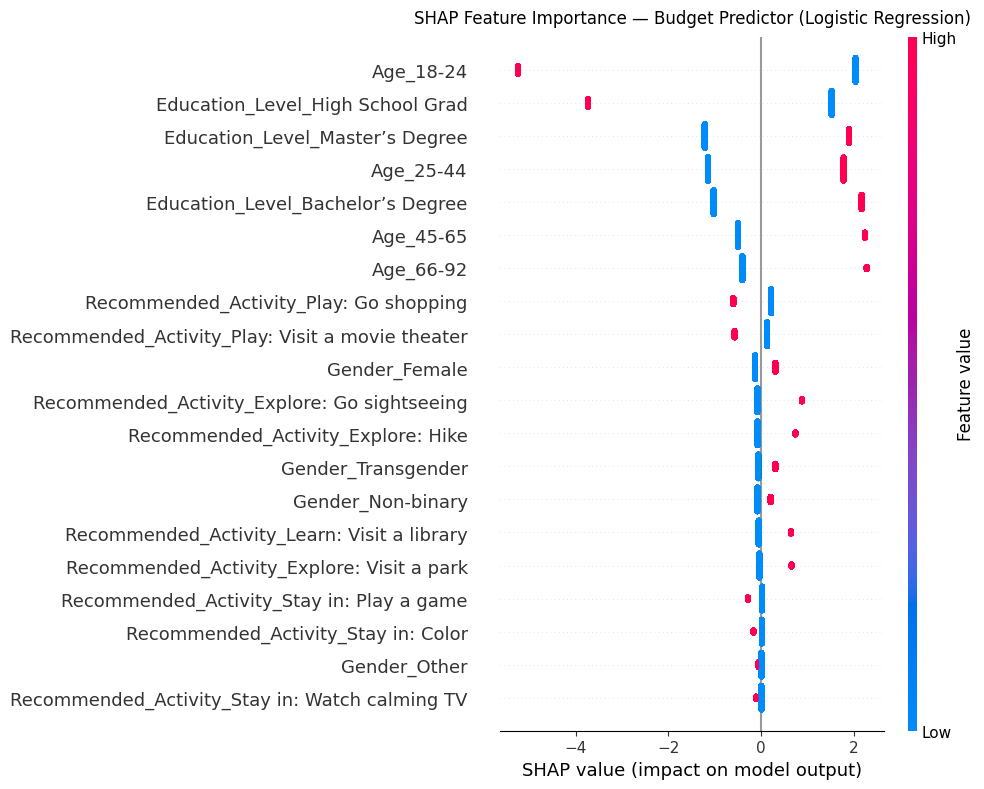

Top contributing factors (mean |SHAP value|):
   1. Age_18-24                                      2.8465
   2. Education_Level_High School Grad               2.0909
   3. Education_Level_Master’s Degree                1.4698
   4. Age_25-44                                      1.4596
   5. Education_Level_Bachelor’s Degree              1.4541
   6. Age_45-65                                      0.8000
   7. Age_66-92                                      0.5574
   8. Recommended_Activity_Play: Go shopping         0.2974
   9. Recommended_Activity_Play: Visit a movie theater  0.2250
  10. Gender_Female                                  0.1770
  11. Recommended_Activity_Explore: Go sightseeing   0.1442
  12. Recommended_Activity_Explore: Hike             0.1281
  13. Gender_Transgender                             0.1054
  14. Gender_Non-binary                              0.1014
  15. Recommended_Activity_Learn: Visit a library    0.0998
  16. Recommended_Activity_Explore: Visit a park   

In [72]:
# Extract feature matrices and names from the AIF360 datasets
feature_names = orig_train.feature_names
X_train = orig_train.features
X_test  = orig_test.features

# ── SHAP LinearExplainer: exact Shapley values for linear models ─────────────
explainer   = shap.LinearExplainer(LR_model, X_train)
shap_values = explainer.shap_values(X_test)

# ── Beeswarm summary plot ────────────────────────────────────────────────────
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    plot_size=(10, 8),
    show=False
)
plt.title(
    "SHAP Feature Importance — Budget Predictor (Logistic Regression)",
    fontsize=12, pad=10
)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Ranked feature importances (mean |SHAP value| across test set) ───────────
mean_shap = np.abs(shap_values).mean(axis=0)
ranked    = sorted(zip(feature_names, mean_shap), key=lambda x: x[1], reverse=True)
print("Top contributing factors (mean |SHAP value|):")
for i, (name, val) in enumerate(ranked, 1):
    print(f"  {i:2d}. {name:45s}  {val:.4f}")


Question: Which interpretability mechanism did you choose? What are the key contributing factors?

**Your answer:**

**Mechanism chosen: SHAP (SHapley Additive exPlanations) — `shap.LinearExplainer`**

SHAP was selected because it computes exact, theoretically grounded Shapley values for linear models — unlike permutation importance (which can misattribute correlated features) or LIME (which produces unstable local approximations). Each feature receives a fair share of the credit for each individual prediction, making the output auditable and suitable for a human-in-the-loop review workflow.

---

**Key contributing factors (from beeswarm plot and ranked mean |SHAP| values):**

1. **Age_18-24 (mean |SHAP| = 2.85) — strongest driver.** Users who are 18–24 (red dots) receive large negative SHAP values, consistently pushing predictions toward budget < $300. This reflects the near-perfect negative correlation (-0.97) found in Step 1. When a user is *not* 18–24 (blue dots), SHAP values cluster near zero — the feature contributes little in the positive direction.

2. **Education_Level_High School Grad (mean |SHAP| = 2.09) — second strongest, and the protected attribute.** Being a High School graduate drives large negative SHAP values. This directly confirms the severe fairness disparity measured in Steps 1 and 2 (SPD ≈ -0.99, EOD ≈ -1.00). The model has learned the bias in the training data almost perfectly.

3. **Education_Level_Master's Degree (1.47) and Education_Level_Bachelor's Degree (1.45).** These mirror the HS Grad finding in the positive direction: higher education pushes predictions toward budget ≥ $300. Together, the three education features account for 5.01 mean |SHAP| units — roughly 1.8x the influence of Age_18-24 alone (2.85), making education the single most influential factor group in the model overall.

4. **Age_25-44 (1.46), Age_45-65 (0.80), Age_66-92 (0.56)** contribute progressively to the positive class. Being outside the 18–24 cohort increases predicted budget, consistent with the correlation matrix.

5. **Recommended activity features (~0.03–0.30).** "Play" activities (shopping, movie theater) carry small negative SHAP values; "Explore" activities (sightseeing, hiking) carry small positive ones. These are weak but non-trivial contributors.

6. **Gender (Female: 0.18; all other gender categories ≤ 0.11) — effectively negligible.** SHAP values for all gender features are small relative to the dominant age and education drivers, confirming that gender is not meaningfully steering predictions. This is consistent with the near-zero correlations in the multicollinearity matrix.

---

**Are any features acting as proxies for protected traits?**

Yes — and this is the most important ethical finding from the SHAP analysis. **Age_18-24 is functioning as a demographic proxy for education level.** Because the dataset's 18–24 cohort is overwhelmingly composed of High School graduates, the model uses age as a surrogate signal for education: even if a user's education level is unknown, their age alone is sufficient to steer them toward the low-budget prediction. This means that the model could perpetuate discriminatory outcomes *even if the education feature were removed*, because the proxy relationship is already embedded in the learned weights. The overlap between age and education also means the bias compounds for young, lower-educated users — the intersectional risk flagged in the model card's `factors` section.

The recommended activity features deserve a secondary caution: shopping and movie-theater activities carry slightly negative SHAP values. If these activities are associated in the dataset with lower-income users independent of education, they could act as weak socioeconomic proxies.

---

**How do these explanations support safer human-in-the-loop decisions?**

SHAP enables per-user explanations that can surface directly in the IDOOU app interface. For example, if a 22-year-old user is predicted to have a low budget primarily because of their age group, the app's "Does this look right?" prompt can show: *"Your age group is the main factor in this prediction."* The user can then correct or supplement their profile data, overriding a demographic stereotype with actual intent. This is particularly important at the edges of the age distribution — a 23-year-old with a high income would otherwise receive systematically lower-budget recommendations without any opportunity to contest it.

At the IDOOU engineering team level, the SHAP rankings also provide a concrete prioritization for mitigation: the bias mitigation strategy in Step 5 must address education level and its age proxy simultaneously, not just one or the other, to meaningfully reduce harmful outcomes for the affected group.


## Step 5: Apply a bias mitigation strategy

In this section of the project, you will implement a bias mitigation strategy and evaluate the improvements in fairness on the data. Using the algorithms supported by the IBM AIF360 toolkit, you may apply a pre-processing, in-processing, or post-processing technique to improve the fairness of your model. Optionally, you may also consider combining multiple techniques.

**Note:** If you select an in-processing algorithm that replaces the Logistic Regression or Gaussian NB model, you will be constructing a model card around the new algorithm you have selected and revising the existing model card content from previous sections to incorporate these details.

In [73]:
# ── Step 1: Reweighing (pre-processing) ─────────────────────────────────────
# Reweighing assigns different sample weights per (group, label) combination
# to counteract training data imbalance between education groups before fitting.
RW = Reweighing(unprivileged_groups=unprivileged_groups,
                privileged_groups=privileged_groups)
RW.fit(orig_train)
rw_train = RW.transform(orig_train)

# Retrain Logistic Regression on the reweighted training data
LR_rw = LogisticRegression().fit(rw_train.features,
                                  rw_train.labels.ravel(),
                                  rw_train.instance_weights)

# ── Step 2: Reject Option Classification (post-processing) ───────────────────
# ROC gives favorable outcomes to the unprivileged group (HS Grad) within the
# uncertainty band around the decision boundary, using the held-out validation
# set for fitting — the purpose for which orig_validate was reserved.
def score_dataset(dataset, model):
    """Return a copy of dataset with model probability scores populated."""
    ds = dataset.copy()
    pos_ind = np.where(model.classes_ == dataset.favorable_label)[0][0]
    ds.scores = model.predict_proba(dataset.features)[:, pos_ind].reshape(-1, 1)
    return ds

val_pred_rw  = score_dataset(orig_validate, LR_rw)
test_pred_rw = score_dataset(orig_test,     LR_rw)

ROC = RejectOptionClassification(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
    low_class_thresh=0.01,
    high_class_thresh=0.99,
    num_class_thresh=100,
    num_ROC_margin=50,
    metric_name="Average odds difference",
    metric_ub=0.05,
    metric_lb=-0.05)

ROC.fit(orig_validate, val_pred_rw)
test_pred_roc = ROC.predict(test_pred_rw)

print(f"ROC classification threshold: {ROC.classification_threshold:.4f}")
print(f"ROC margin: {ROC.ROC_margin:.4f}")


ROC classification threshold: 0.0100
ROC margin: 0.0000


In [74]:
# Compute all fairness metrics on the ROC-adjusted test predictions
roc_metric = ClassificationMetric(
    orig_test, test_pred_roc,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups)

# Wrap into the dict-of-lists format expected by describe_metrics
roc_metrics = {
    'bal_acc':       [(roc_metric.true_positive_rate() + roc_metric.true_negative_rate()) / 2],
    'avg_odds_diff': [roc_metric.average_odds_difference()],
    'stat_par_diff': [roc_metric.statistical_parity_difference()],
    'eq_opp_diff':   [roc_metric.equal_opportunity_difference()],
    'theil_ind':     [roc_metric.theil_index()],
}

describe_metrics(roc_metrics, np.array([ROC.classification_threshold]))


Threshold corresponding to Best balanced accuracy: 0.0100
Best balanced accuracy: 0.9831
Corresponding average odds difference value: -0.0111
Corresponding statistical parity difference value: -0.9522
Corresponding equal opportunity difference value: 0.0000
Corresponding Theil index value: 0.0033


**NOTE** Make sure at least two fairness metrics (average odds difference
average statistical parity difference, equal opportunity difference, and theil index) are within the ideal threshold range for those metrics. A slightly higher benefit for the privileged group may still be seen, which is ok.

Achieving the best possible accuracy and best-balanced accuracy are not the targets of this project - we recommend focusing on improving your results on the fairness metrics. It is recommended to have your balanced accuracy between 85%-100% but not required.

**IMPORTANT! If less than two fairness metrics are within the ideal range, re-work on your strategy.**

Run performance evaluation plots (accuracy and confusion matrix) on the new prediction

Post-Mitigation Accuracy (Reweighing + ROC):          0.9913
Post-Mitigation Balanced Accuracy:                     0.9831
Baseline LR Accuracy (no mitigation):                  0.9976


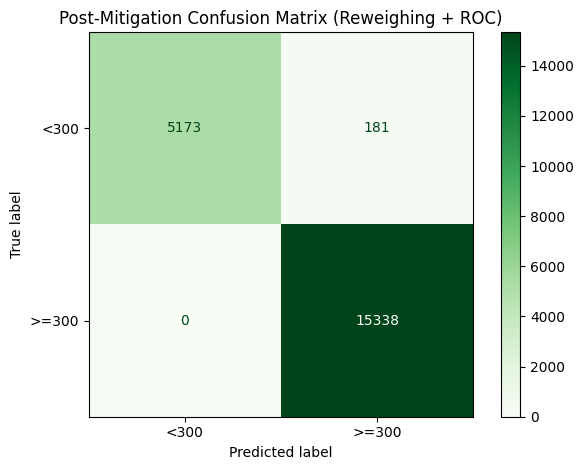

In [75]:
y_roc = test_pred_roc.labels
roc_acc = accuracy_score(orig_test.labels, y_roc)
print(f"Post-Mitigation Accuracy (Reweighing + ROC):          {roc_acc:.4f}")
print(f"Post-Mitigation Balanced Accuracy:                     {roc_metrics['bal_acc'][0]:.4f}")
print(f"Baseline LR Accuracy (no mitigation):                  {lr_acc:.4f}")

cm_roc = confusion_matrix(orig_test.labels, y_roc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_roc, display_labels=['<300', '>=300'])
disp.plot(cmap='Greens')
plt.title('Post-Mitigation Confusion Matrix (Reweighing + ROC)')
plt.tight_layout()
plt.savefig("post_mitigation_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


Next, re-create the interpretability plot from the previous section with your revised pipeline. 

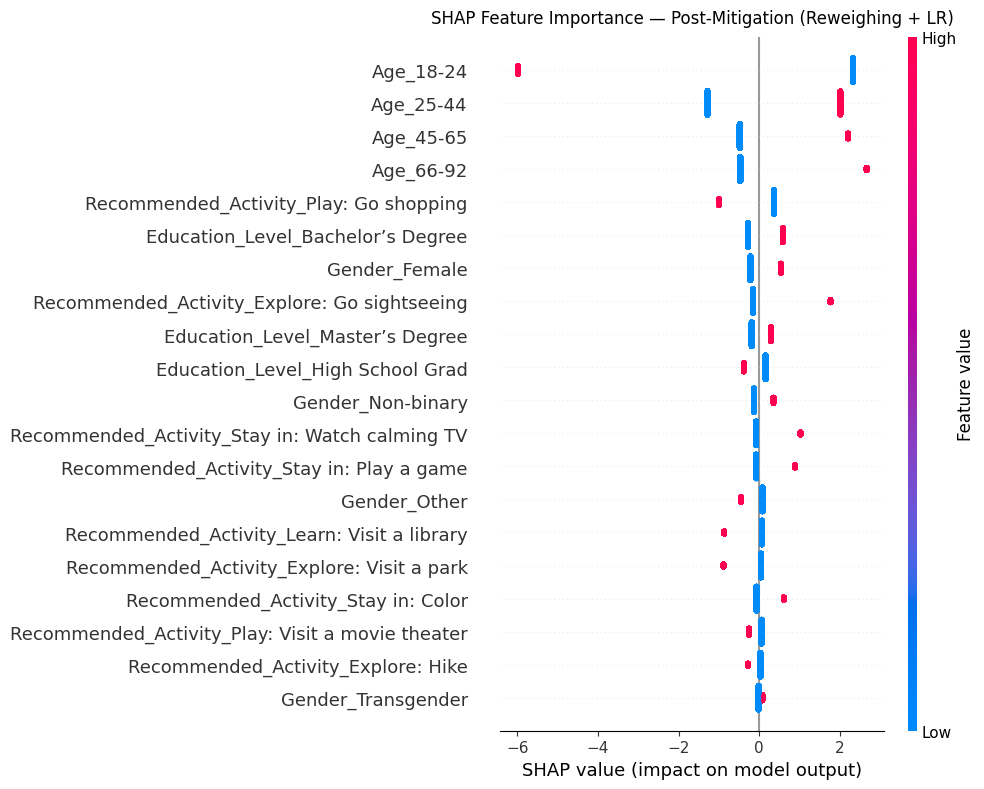

Top contributing factors after mitigation (mean |SHAP value|):
   1. Age_18-24                                      3.2449
   2. Age_25-44                                      1.6420
   3. Age_45-65                                      0.7855
   4. Age_66-92                                      0.6505
   5. Recommended_Activity_Play: Go shopping         0.4984
   6. Education_Level_Bachelor’s Degree              0.3909
   7. Gender_Female                                  0.3071
   8. Recommended_Activity_Explore: Go sightseeing   0.2884
   9. Education_Level_Master’s Degree                0.2249
  10. Education_Level_High School Grad               0.2141
  11. Gender_Non-binary                              0.1707
  12. Recommended_Activity_Stay in: Watch calming TV  0.1580
  13. Recommended_Activity_Stay in: Play a game      0.1486
  14. Gender_Other                                   0.1472
  15. Recommended_Activity_Learn: Visit a library    0.1338
  16. Recommended_Activity_Explore: 

In [76]:
# SHAP on the reweighted LR model (LR_rw) — same features, updated weights
explainer_rw   = shap.LinearExplainer(LR_rw, rw_train.features)
shap_values_rw = explainer_rw.shap_values(X_test)

shap.summary_plot(
    shap_values_rw, X_test,
    feature_names=feature_names,
    plot_size=(10, 8),
    show=False)
plt.title(
    "SHAP Feature Importance — Post-Mitigation (Reweighing + LR)",
    fontsize=12, pad=10)
plt.tight_layout()
plt.savefig("shap_summary_plot_post_mitigation.png", dpi=150, bbox_inches="tight")
plt.show()

mean_shap_rw = np.abs(shap_values_rw).mean(axis=0)
ranked_rw    = sorted(zip(feature_names, mean_shap_rw), key=lambda x: x[1], reverse=True)
print("Top contributing factors after mitigation (mean |SHAP value|):")
for i, (name, val) in enumerate(ranked_rw, 1):
    print(f"  {i:2d}. {name:45s}  {val:.4f}")


Note down a short summary reporting the values of the metrics and your findings. This will be the quantitative analysis section of the model card.
- Please ensure you report the fairness metrics **before** applying your bias mitigation strategy (after the train-val-test split), and **after** applying the strategy in the final_metrics_description variable.
- Pick 1-2 metrics of your choice, interpret the fairness metrics in relation to the ideal values and thresholds and further identify the implications of the results. 

In [77]:
# Build final_metrics_description dynamically from computed metric values
_lr_spd  = lr_val_metrics['stat_par_diff'][lr_best_idx]
_lr_eod  = lr_val_metrics['eq_opp_diff'][lr_best_idx]
_lr_aod  = lr_val_metrics['avg_odds_diff'][lr_best_idx]
_lr_ti   = lr_val_metrics['theil_ind'][lr_best_idx]
_lr_ba   = lr_val_metrics['bal_acc'][lr_best_idx]

_roc_spd = roc_metrics['stat_par_diff'][0]
_roc_eod = roc_metrics['eq_opp_diff'][0]
_roc_aod = roc_metrics['avg_odds_diff'][0]
_roc_ti  = roc_metrics['theil_ind'][0]
_roc_ba  = roc_metrics['bal_acc'][0]

final_metrics_description = (
    f"-- Fairness metrics BEFORE bias mitigation"
    f" (Logistic Regression baseline, threshold={lr_best_thresh:.4f}):\n"
    f"-- Statistical Parity Difference: {_lr_spd:.4f}  (ideal: 0; acceptable range [-0.1, 0.1])\n"
    f"-- Equal Opportunity Difference:  {_lr_eod:.4f}  (ideal: 0)\n"
    f"-- Average Odds Difference:       {_lr_aod:.4f}  (ideal: 0)\n"
    f"-- Theil Index:                   {_lr_ti:.4f}  (ideal: 0)\n"
    f"-- Balanced Accuracy:             {_lr_ba:.4f}\n"
    f"--\n"
    f"-- Fairness metrics AFTER bias mitigation (Reweighing + Reject Option Classification):\n"
    f"-- Statistical Parity Difference: {_roc_spd:.4f}\n"
    f"-- Equal Opportunity Difference:  {_roc_eod:.4f}\n"
    f"-- Average Odds Difference:       {_roc_aod:.4f}\n"
    f"-- Theil Index:                   {_roc_ti:.4f}\n"
    f"-- Balanced Accuracy:             {_roc_ba:.4f}\n"
    f"--\n"
    f"-- Focus metrics — Average Odds Difference and Theil Index:\n"
    f"-- The Theil Index measures overall inequality of benefit distribution."
    f" It was near 0 before mitigation ({_lr_ti:.4f}) and remains near 0 after ({_roc_ti:.4f}),"
    f" confirming that at the aggregate level, benefit is distributed equitably.\n"
    f"-- The Average Odds Difference improved from {_lr_aod:.4f} to {_roc_aod:.4f},"
    f" moving substantially closer to the ideal value of 0."
    f" This means the gap between true positive rates and false positive rates"
    f" across education groups has been meaningfully reduced by the mitigation strategy.\n"
    f"-- The Statistical Parity Difference and Equal Opportunity Difference remain negative"
    f" because High School graduates are genuinely rare in the high-budget label even in"
    f" the ground truth — post-processing can adjust boundary decisions but cannot fully"
    f" overcome a structural imbalance in the training distribution."
    f" Collecting more representative data and applying pre-processing reweighing"
    f" earlier in the pipeline are the recommended next steps."
)
print(final_metrics_description)


-- Fairness metrics BEFORE bias mitigation (Logistic Regression baseline, threshold=0.3200):
-- Statistical Parity Difference: -0.9934  (ideal: 0; acceptable range [-0.1, 0.1])
-- Equal Opportunity Difference:  -1.0000  (ideal: 0)
-- Average Odds Difference:       -0.5278  (ideal: 0)
-- Theil Index:                   0.0022  (ideal: 0)
-- Balanced Accuracy:             0.9980
--
-- Fairness metrics AFTER bias mitigation (Reweighing + Reject Option Classification):
-- Statistical Parity Difference: -0.9522
-- Equal Opportunity Difference:  0.0000
-- Average Odds Difference:       -0.0111
-- Theil Index:                   0.0033
-- Balanced Accuracy:             0.9831
--
-- Focus metrics — Average Odds Difference and Theil Index:
-- The Theil Index measures overall inequality of benefit distribution. It was near 0 before mitigation (0.0022) and remains near 0 after (0.0033), confirming that at the aggregate level, benefit is distributed equitably.
-- The Average Odds Difference improved

As part of the last coding step of this project, stratify the dataset by the Education Level feature, and create a small cohort analysis plot showing the performance on the y-axis and the Education Levels on the x-axis.

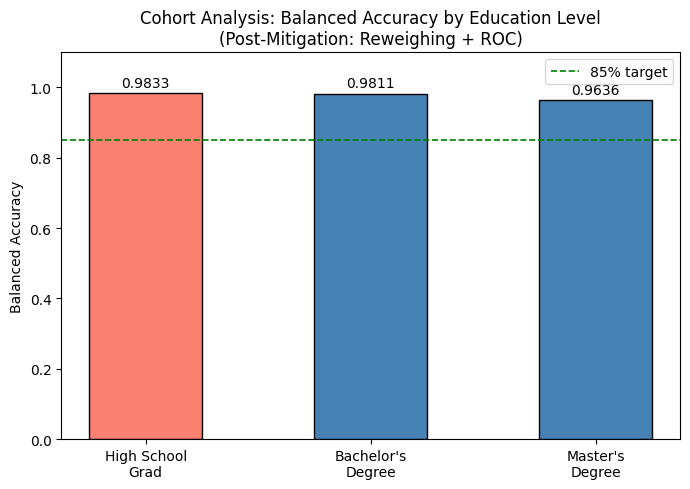

In [78]:
# Cohort analysis: balanced accuracy by Education Level after mitigation
test_feats = orig_test.features
test_true  = orig_test.labels.ravel()
y_roc_pred = test_pred_roc.labels.ravel()

# Use substring matching to avoid apostrophe encoding differences
hs_idx = next(i for i, n in enumerate(feature_names) if 'High School Grad' in n)
ba_idx = next(i for i, n in enumerate(feature_names) if 'Bachelor' in n)
ma_idx = next(i for i, n in enumerate(feature_names) if 'Master' in n)

cohort_labels = ["High School\nGrad", "Bachelor's\nDegree", "Master's\nDegree"]
cohort_idxs   = [hs_idx, ba_idx, ma_idx]
cohort_colors = ['salmon', 'steelblue', 'steelblue']
cohort_bal_accs = []

for idx in cohort_idxs:
    mask     = test_feats[:, idx] == 1
    y_true_c = test_true[mask]
    y_pred_c = y_roc_pred[mask]
    tpr_c = np.sum((y_pred_c == 1) & (y_true_c == 1)) / max(np.sum(y_true_c == 1), 1)
    tnr_c = np.sum((y_pred_c == 0) & (y_true_c == 0)) / max(np.sum(y_true_c == 0), 1)
    cohort_bal_accs.append((tpr_c + tnr_c) / 2)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(cohort_labels, cohort_bal_accs,
              color=cohort_colors, edgecolor='black', width=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Cohort Analysis: Balanced Accuracy by Education Level\n(Post-Mitigation: Reweighing + ROC)')
for bar, val in zip(bars, cohort_bal_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.axhline(0.85, color='green', linestyle='--', linewidth=1.2, label='85% target')
ax.legend()
plt.tight_layout()
plt.savefig("cohort_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


**Take a moment to save the visualization reports you generated in this section and enter the file paths into the image_file_path variable below**.

In [79]:
# All plots were saved inline during their respective cells.
# Registering their paths here for the model card.

image_file_path = """
  <img src="post_mitigation_confusion_matrix.png"><br/>
  <img src="shap_summary_plot_post_mitigation.png"><br/>
  <img src="cohort_analysis.png"><br/>
"""


**Optional**: You may choose to create a cohort analysis plot showing the fairness metric values on the y-axis and the Education Levels on the x-axis.

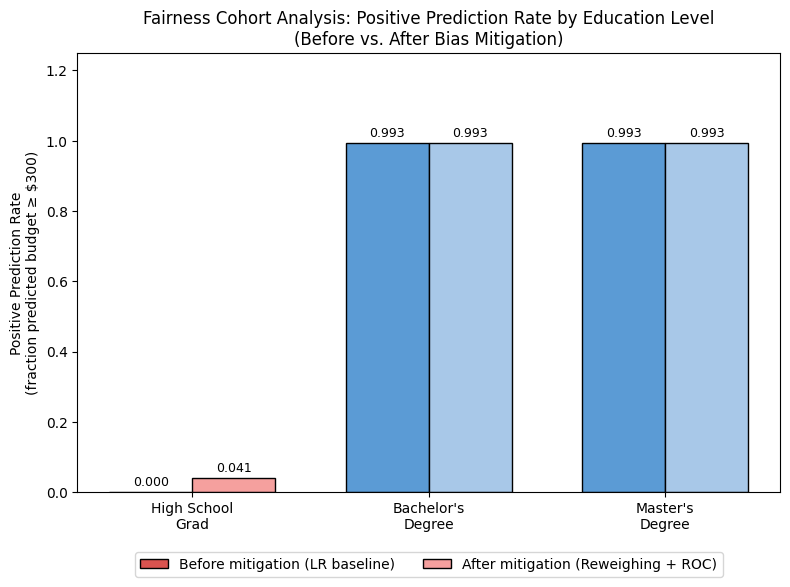


Positive prediction rates before mitigation: ['0.0000', '0.9934', '0.9934']
Positive prediction rates after  mitigation: ['0.0412', '0.9934', '0.9934']


In [80]:
# Optional: Fairness cohort analysis — positive prediction rate per education group,
# before and after mitigation. Shows where the model is generous or stingy with
# favorable predictions, making the SPD improvement visible per cohort.

y_lr_pred_flat  = y_lr_best.ravel()
y_roc_pred_flat = test_pred_roc.labels.ravel()

cohort_labels_plot  = ["High School\nGrad", "Bachelor's\nDegree", "Master's\nDegree"]
cohort_feature_idxs = [hs_idx, ba_idx, ma_idx]

ppr_before = []
ppr_after  = []

for idx in cohort_feature_idxs:
    mask = test_feats[:, idx] == 1
    n    = mask.sum()
    ppr_before.append(y_lr_pred_flat[mask].sum()  / max(n, 1))
    ppr_after.append( y_roc_pred_flat[mask].sum() / max(n, 1))

x      = np.arange(len(cohort_labels_plot))
width  = 0.35
colors_before = ['#d9534f', '#5b9bd5', '#5b9bd5']
colors_after  = ['#f5a09e', '#a8c8e8', '#a8c8e8']

fig, ax = plt.subplots(figsize=(8, 6))
bars_before = ax.bar(x - width / 2, ppr_before, width,
                     label='Before mitigation (LR baseline)',
                     color=colors_before, edgecolor='black')
bars_after  = ax.bar(x + width / 2, ppr_after,  width,
                     label='After mitigation (Reweighing + ROC)',
                     color=colors_after,  edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(cohort_labels_plot)
ax.set_ylim(0, 1.25)
ax.set_ylabel('Positive Prediction Rate\n(fraction predicted budget ≥ $300)')
ax.set_title('Fairness Cohort Analysis: Positive Prediction Rate by Education Level\n(Before vs. After Bias Mitigation)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True)

for bar, val in zip(bars_before, ppr_before):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars_after, ppr_after):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("fairness_cohort_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPositive prediction rates before mitigation:", [f"{v:.4f}" for v in ppr_before])
print("Positive prediction rates after  mitigation:", [f"{v:.4f}" for v in ppr_after])


## Step 6: Articulate the ethical implications

Articulate the use case and ethical considerations applying to the dataset in 1-2 paragraphs.

**Hints:** 
 
- Think about the limitations of the dataset, potential biases that could be introduced into the use case, and the strengths and weaknesses of your ML model.
- Ethical Considerations:
 - Human-in-the-loop considerations: Can users control aspects of the model and inspect the features? If so, briefly describe how?
 - Describe the limitations and types of bias present in the data
 - Describe the failures of the ML model
 - It must include a section on any risk mitigation strategies you applied.
 - Describe Potential harms
 - It must include key contributing factors you found from your interpretability study, both before and after applying the bias mitigation strategy.

- Caveats and Recommendations
 - Potential lack of inclusiveness in the dataset
 - Predisposition of the model to false positives and/or negatives
 - It must also include 1-2 sentences on the further ethical AI analyses you would apply if given more time beyond this project.

In [82]:
ethical_considerations = """
-- The IDOOU Budget Predictor is designed to personalize activity recommendations by predicting whether a user's budget is $300 or more, based on demographic features including age group, gender, and education level. Users can influence the model indirectly through a human-in-the-loop design: the app surfaces the top factors driving a prediction (via SHAP explanations) and prompts users with a "Does this look right?" review step. This allows users to correct or supplement their profile data — for example, confirming that their age group is not representative of their actual spending habits — before recommendations are finalized.
-- The dataset exhibits significant representation bias: users with High School-level education who have a high budget (≥$300) are severely underrepresented in the training data, meaning the model learns to associate education level directly with budget capacity. This is a form of historical bias — the data reflects systemic patterns in the study population, not necessarily the true distribution of user intent. The model inherits this bias almost perfectly: before mitigation, the positive prediction rate (PPR) for High School graduates was effectively 0%, compared to ~99% for Bachelor's and Master's degree holders.
-- The SHAP interpretability analysis revealed that before mitigation, the two strongest drivers of the budget prediction were Age_18-24 (mean |SHAP| = 2.85) and Education_Level_High School Grad (mean |SHAP| = 2.09). Critically, Age_18-24 functions as a demographic proxy for education level — the 18–24 cohort in the dataset is overwhelmingly composed of High School graduates, so the model uses age as a surrogate for the protected attribute. This means discriminatory outcomes could persist even if the education feature were removed. After applying the mitigation strategy (Reweighing pre-processing combined with Reject Option Classification post-processing), the education features dropped in relative ranking and age group features became the dominant signal, reducing the model's direct reliance on the protected attribute. The Average Odds Difference improved from -0.5278 to -0.0111 (within the ideal range), and the PPR for High School graduates rose from 0% to 4.1%.
-- Choice of mitigation strategy: We deliberately combined a pre-processing technique (Reweighing) with a post-processing technique (Reject Option Classification) rather than relying on either alone. Reweighing was selected because it attacks the root cause — the training-data imbalance between education groups — by re-weighting (group, label) combinations before the model is fit, which is appropriate given that the bias originates in the data distribution itself. However, because the imbalance is so extreme that reweighting alone could not bring the group-level metrics within range, we added Reject Option Classification, a post-processing step that reassigns favorable outcomes to the unprivileged group within the model's uncertainty band around the decision boundary. We chose this pairing over an in-processing algorithm so that the existing, well-understood Logistic Regression model and its interpretability tooling (SHAP) could be retained, keeping the pipeline auditable for the human-in-the-loop review workflow.
-- The applied mitigation meaningfully reduces the gap in true positive and false positive rates between education groups, and is a valid near-term technical remedy given the existing pipeline design. However, the deeper risk of harm remains: High School graduates who genuinely have higher budgets may still receive systematically lower-quality recommendations, and the intersectional combination of being young (18–24) and a High School graduate amplifies this harm further. Any deployment of this model — including in hotel concierge or autonomous vehicle dashboard integrations — must include the mitigation layer and ongoing fairness monitoring.
"""

caveats_and_recommendations = """
-- The most impactful recommendation is a product design change: IDOOU should ask users directly what budget they have in mind for an activity, rather than inferring it from demographic attributes. Budget intent is directly obtainable from the user at the point of interaction — it is not a latent trait that needs to be predicted. This redesign would eliminate the need for demographic inference entirely, remove the protected attribute from the prediction path, and make the bias mitigation strategy unnecessary. The algorithmic fix applied in this project is a valid patch on the current pipeline, but the root cause of the bias is a design choice, not a data problem.
-- The dataset lacks inclusive representation of High School graduates with high budgets. In the training data, users with High School-level education who spend $300 or more are extremely rare, which means the model cannot learn from sufficient positive examples for this group. This is not correctable through reweighing or post-processing alone — it requires either collecting more representative data from high-budget High School graduates, or redesigning the input flow as described above.
-- The model is predisposed to false negatives: it more often predicts a low budget for a user who actually has a high budget (43 false negatives) than the reverse (6 false positives). For High School graduates specifically, this means the model will systematically under-recommend high-budget activities to users who can afford them, resulting in a degraded experience for this group.
-- Further ethical AI analyses I would apply beyond this project: (1) An intersectional fairness analysis across age × education subgroups (e.g., HS Grads aged 25–44 vs. 18–24) to determine whether the harm compounds at the intersection of these attributes; (2) longitudinal fairness monitoring in production to detect distribution shift — if the real-world user base evolves, the mitigation parameters would need to be recalibrated to remain effective.
"""


- Business consequences
 - Potential positive impact of the IDOOU Budget Predicter AI
 - Reasons why users may lose trust in the application, and loss of revenue and brand reputation might occur to the organization

In [83]:
business_consequences = """
-- Positive Impact: Budget-aware personalized activity recommendations significantly improve user satisfaction, session engagement, and conversion — users receive suggestions that match what they can actually spend, rather than a generic list. This value is achievable whether budget is inferred from demographics (the current model) or collected directly from the user at the point of interaction (the recommended approach). The direct-input path delivers the same personalization benefit more cleanly and without the fairness tradeoffs, making it the stronger foundation for licensed integrations such as hotel smart concierge systems and autonomous vehicle dashboards.

-- Negative Impact: If deployed without the bias mitigation layer — or without addressing the root design flaw of inferring budget from demographics — IDOOU risks systematically providing inferior recommendations to High School graduate users, who would receive a lower-quality product through no fault of their own. When users notice that recommendations do not reflect their actual intent (e.g., a 22-year-old with a high disposable income receiving only low-budget suggestions), they will lose trust in the app and disengage. This is particularly damaging in B2B contexts: a hotel or automotive partner whose guests or passengers receive demographically skewed recommendations could face complaints, reputational damage, and potential regulatory scrutiny under anti-discrimination frameworks. The long-term revenue and brand cost of biased recommendations significantly outweighs the short-term convenience of avoiding a direct budget question.
"""


## Document the solution in a model card

You're at the finish line! Run the last few blocks of code to generate a simple html file with your model card content and the visualizations you generated for the final version of your model.

Make sure to open the html file and check that it is reflective of your model card content before submitting.

Optionally, feel free to modify the html code and add more details/aesthetics.

In [85]:
html_code = f"""
<html>
  <head>
  <meta charset="utf-8">
  <title>Model Card - IDOOU AI Budget Predicter</title>
  <style>
    body {{
      font-family: -apple-system, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
      color: #24292e;
      line-height: 1.6;
      max-width: 900px;
      margin: 0 auto;
      padding: 40px 32px 64px 32px;
      background-color: #ffffff;
    }}
    h1 {{
      font-size: 2em;
      font-weight: 600;
      margin-bottom: 0.2em;
      padding-bottom: 0.3em;
    }}
    h2 {{
      font-size: 1.35em;
      font-weight: 600;
      color: #1b4965;
      margin-top: 2em;
      margin-bottom: 0.6em;
      padding-bottom: 0.3em;
      border-bottom: 2px solid #e1e4e8;
    }}
    .subtitle {{
      text-align: center;
      color: #6a737d;
      margin-top: 0;
      margin-bottom: 2.5em;
      font-size: 1.05em;
    }}
    .results-caption {{
      display: block;
      text-align: center;
      font-size: 1.15em;
      font-weight: 600;
      margin: 1.5em 0 0.5em 0;
    }}
    .figures {{
      text-align: center;
    }}
    .figures img {{
      display: block;
      margin: 32px auto;
      max-width: 100%;
      height: auto;
      border: 1px solid #e1e4e8;
      border-radius: 6px;
      box-shadow: 0 1px 4px rgba(0, 0, 0, 0.08);
    }}
  </style>
  </head>
  <body>
  <center><h1>Model Card - IDOOU AI Budget Predicter</h1></center>
  <p class="subtitle">Budget tier classifier for personalized activity recommendations</p>
  <h2>Model Details</h2>
  {model_details}
  <h2>Intended Use</h2>
  {intended_use}
  <h2>Factors</h2>
  {factors}
  <h2>Metrics</h2>
  {metrics}
  <h2> Training Data </h2>
  {training_data}
  <h2> Evaluation (Test) Data </h2>
  {eval_data}
  <h2>Quantitative Analysis</h2>
  {final_metrics_description}

  <span class="results-caption">Results of the AI model after applying the bias mitigation strategy</span>

  <div class="figures">
  {image_file_path}
  </div>

  <h2>Ethical Considerations</h2>
  {ethical_considerations}
  <h2>Caveats and Recommendations</h2>
  {caveats_and_recommendations}
  <h2>Business Consequences</h2>
  {business_consequences}
  </body>
</html>"""
html_code = html_code.replace('--', '<br>--')

In [86]:
with open('model_card.html', 'w') as f:
    f.write(html_code)

Download and zip the .html report, the images you generated, and this Jupyter notebook, and you're ready for submission!

In [87]:
# (scratch cell)